In [ ]:
pip install pybbn

  Preparing metadata (setup.py) ... done
  Created wheel for pybbn: filename=pybbn-3.2.3-py3-none-any.whl size=40372 sha256=d7d6d141038cb734e568487d66ee0730386263ed0686acb291c4775a3a325d05
  Stored in directory: /root/.cache/pip/wheels/97/20/85/52b65994184561eecc73318b47effb93e250a3dc3264db32c9
Successfully built pybbn


In [ ]:
import pandas as pd # for data manipulation
import networkx as nx # for drawing graphs
import matplotlib.pyplot as plt # for drawing graphs
# for creating Bayesian Belief Networks (BBN)
from pybbn.graph.dag import Bbn
from pybbn.graph.edge import Edge, EdgeType
from pybbn.graph.jointree import EvidenceBuilder
from pybbn.graph.node import BbnNode
from pybbn.graph.variable import Variable
from pybbn.pptc.inferencecontroller import InferenceController
#Set Pandas options to display more columns
pd.options.display.max_columns=50

# Read in the weather data csv
# Load dataset
df = pd.read_csv('weatherAUS.csv', encoding='utf-8')

# Drop rows where target is missing
df = df[df['RainTomorrow'].notnull()]

# Fill missing values with mean (numeric columns)
df = df.fillna(df.mean(numeric_only=True))

# Create categorical bands
df['WindGustSpeedCat'] = df['WindGustSpeed'].apply(
    lambda x: '<=40' if x <= 40 else '40-50' if x <= 50 else '>50'
)

df['Humidity9amCat'] = df['Humidity9am'].apply(
    lambda x: '>60' if x > 60 else '<=60'
)

df['Humidity3pmCat'] = df['Humidity3pm'].apply(
    lambda x: '>60' if x > 60 else '<=60'
)

In [ ]:
def probs(data, child, parent1=None, parent2=None):
    if parent1 is None:
        prob = pd.crosstab(data[child], 'count', normalize='columns') \
                .sort_index().to_numpy().reshape(-1).tolist()

    elif parent2 is None:
        prob = pd.crosstab(data[parent1], data[child], normalize='index') \
                .sort_index().to_numpy().reshape(-1).tolist()

    else:
        prob = pd.crosstab([data[parent1], data[parent2]], data[child],
                           normalize='index') \
                .sort_index().to_numpy().reshape(-1).tolist()

    return prob

In [ ]:
H9am = BbnNode(
    Variable(0, 'H9am', ['<=60', '>60']),
    probs(df, child='Humidity9amCat')
)

H3pm = BbnNode(
    Variable(1, 'H3pm', ['<=60', '>60']),
    probs(df, child='Humidity3pmCat', parent1='Humidity9amCat')
)

W = BbnNode(
    Variable(2, 'W', ['<=40', '40-50', '>50']),
    probs(df, child='WindGustSpeedCat')
)

RT = BbnNode(
    Variable(3, 'RT', ['No', 'Yes']),
    probs(df, child='RainTomorrow',
          parent1='Humidity3pmCat',
          parent2='WindGustSpeedCat')
)

In [ ]:
bbn = Bbn() \
    .add_node(H9am) \
    .add_node(H3pm) \
    .add_node(W) \
    .add_node(RT) \
    .add_edge(Edge(H9am, H3pm, EdgeType.DIRECTED)) \
    .add_edge(Edge(H3pm, RT, EdgeType.DIRECTED)) \
    .add_edge(Edge(W, RT, EdgeType.DIRECTED))

# Convert to Join Tree
join_tree = InferenceController.apply(bbn)

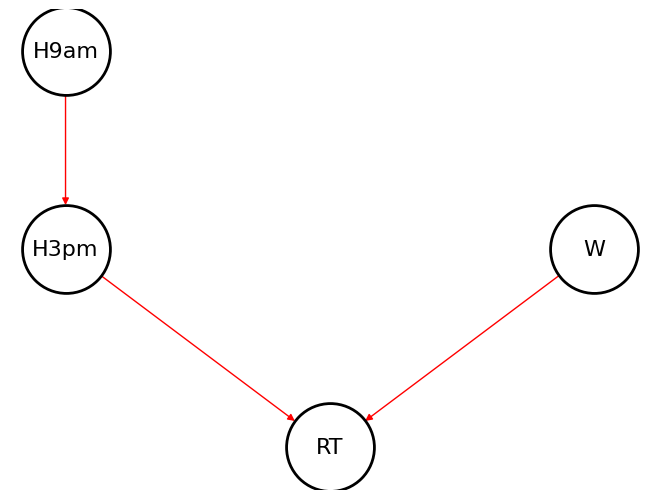

In [ ]:
pos = {
    0: (-1, 2),
    1: (-1, 0.5),
    2: (1, 0.5),
    3: (0, -1)
}

# Graph styling
options = {
    "font_size": 16,
    "node_size": 4000,
    "node_color": "white",
    "edgecolors": "black",
    "edge_color": "red",
    "linewidths": 2,
}

# Draw graph
n, labels = bbn.to_nx_graph()
nx.draw(n, with_labels=True, labels=labels, pos=pos, **options)

plt.axis("off")
plt.show()